Saving Sleep_health_and_lifestyle_dataset.csv to Sleep_health_and_lifestyle_dataset (1).csv
First 5 rows:
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Slee

/tmp/ipykernel_9527/325786616.py:52: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Sleep Disorder"] = df["Sleep Disorder"].replace({



===== Logistic Regression =====
Accuracy: 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.91      0.94      0.92        32

    accuracy                           0.93        75
   macro avg       0.93      0.93      0.93        75
weighted avg       0.93      0.93      0.93        75



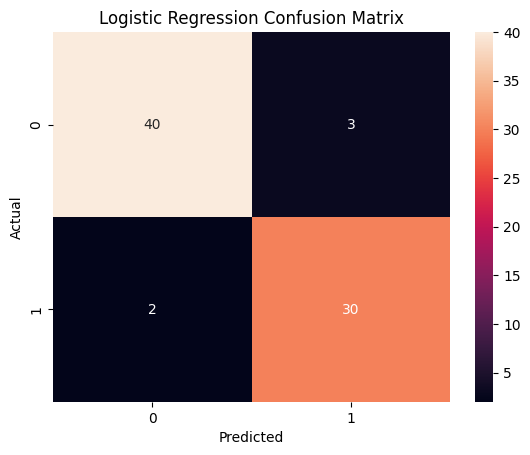


===== Random Forest =====
Accuracy: 0.96

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97        43
           1       0.97      0.94      0.95        32

    accuracy                           0.96        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.96      0.96      0.96        75



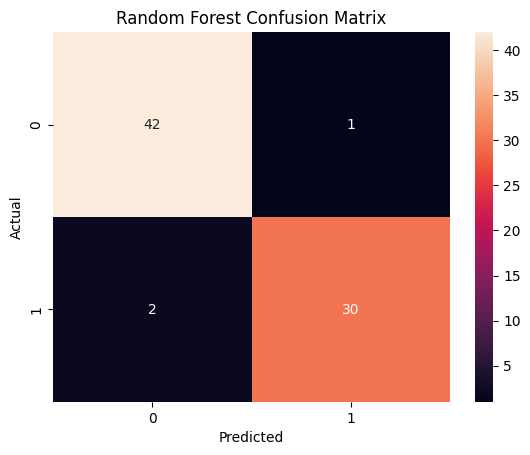


Feature Importance:
                     Feature  Importance
7              BMI Category    0.332948
8            Blood Pressure    0.174399
2                Occupation    0.170269
3            Sleep Duration    0.113380
1                       Age    0.088484
9                Heart Rate    0.036476
6              Stress Level    0.026345
4          Quality of Sleep    0.019720
10              Daily Steps    0.019404
5   Physical Activity Level    0.014238
0                    Gender    0.004336


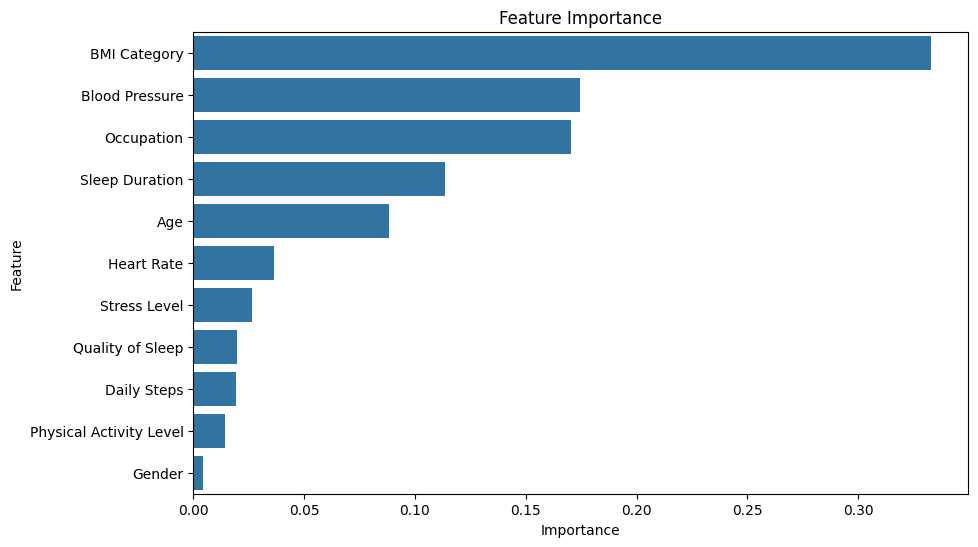

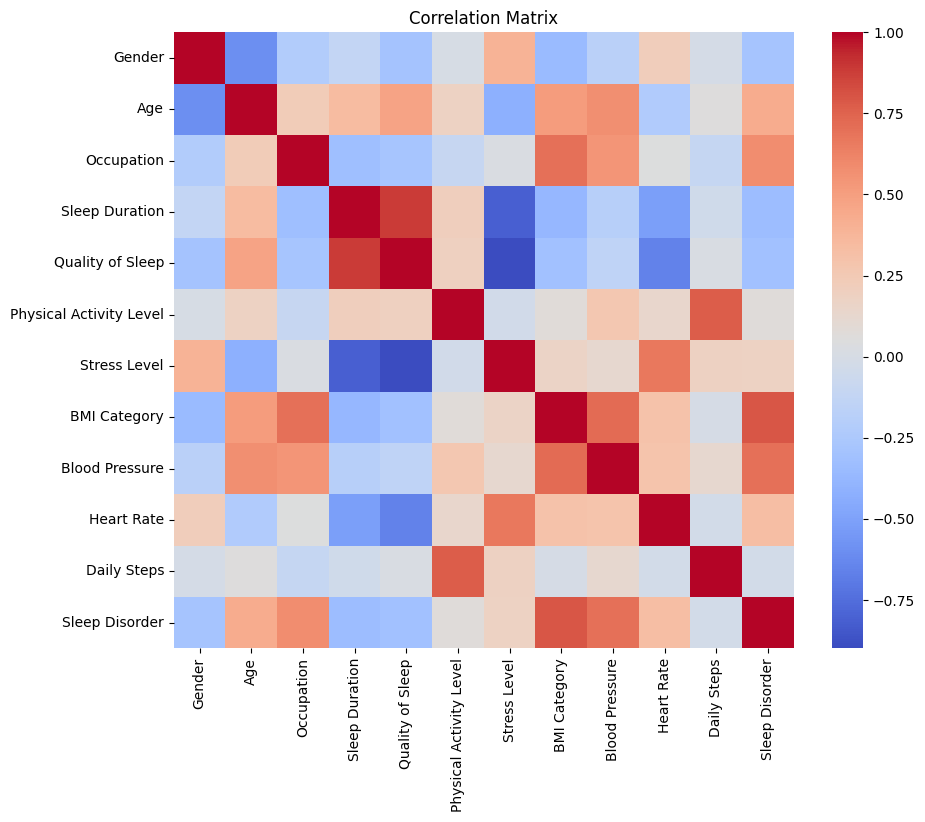

In [2]:
# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# UPLOAD FILE
# =========================
from google.colab import files
uploaded = files.upload()

# =========================
# LOAD DATA (Excel or CSV safe)
# =========================
file_name = list(uploaded.keys())[0]

if file_name.endswith(".csv"):
    df = pd.read_csv(file_name)
else:
    df = pd.read_excel(file_name)

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

# =========================
# CLEANING (FIXED)
# =========================
if "Person ID" in df.columns:
    df = df.drop("Person ID", axis=1)

# IMPORTANT FIX: DO NOT DROP NA ROWS (this was breaking your model)
# Instead, treat missing Sleep Disorder as "None"
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

# =========================
# BINARY TARGET CONVERSION
# =========================
df["Sleep Disorder"] = df["Sleep Disorder"].replace({
    "None": 0,
    "Insomnia": 1,
    "Sleep Apnea": 1
})

# =========================
# ENCODE CATEGORICAL FEATURES
# =========================
label_encoders = {}

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# =========================
# FEATURES & TARGET
# =========================
X = df.drop("Sleep Disorder", axis=1)
y = df["Sleep Disorder"]

print("\nClass Distribution:")
print(y.value_counts())

# =========================
# TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# SCALING
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# MODELS
# =========================
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# =========================
# EVALUATION FUNCTION
# =========================
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# =========================
# RESULTS
# =========================
evaluate_model(log_model, X_test_scaled, y_test, "Logistic Regression")
evaluate_model(rf_model, X_test, y_test, "Random Forest")

# =========================
# FEATURE IMPORTANCE
# =========================
importances = rf_model.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n", feat_df)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Feature Importance")
plt.show()

# =========================
# CORRELATION HEATMAP
# =========================
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()